# Example

In [30]:
import os
print(os.getcwd())
import silmaril
from silmaril import *


/Users/lamoreau/pyS99/pyS99/nbs_etc


In [31]:
# import silmaril
import yt
import numpy as np
from astropy.wcs import WCS
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from silmaril.lens import Lens
from silmaril.utilities import Grid
from astropy.io import fits
from scipy.ndimage import map_coordinates
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

In [32]:
s = SkyCoord(24.3468342,-8.4645026,unit="deg")
image_plane = utilities.Grid(s,1000,0.031)
# wcs = WCS(fits.open('hlsp_relics_model_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits')[0].header)
# --- Lens setup ---
x_file_name = "../silmaril/docs/source/notebooks/hlsp_relics_model_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits"
x_deflections = fits.getdata(x_file_name) 
y_deflections = fits.getdata("../silmaril/docs/source/notebooks/hlsp_relics_model_model_whl0137-08_glafic_v1_y-arcsec-deflect.fits") 
hdr = fits.getheader(x_file_name)
wcs = WCS(hdr)

# # --- Create Lens object at redshit, z=2 ---
# lens = Lens(x_defl, y_defl, wcs=lens_wcs, redshift=2, unit = "arcsec")

In [33]:
lens = Lens(x_deflections,y_deflections,wcs,redshift=0.566,unit='arcsec')
detector = imaging.Detector(resolution=0.031,fov=30,center=SkyCoord(24.34819561, -8.46520946,unit="deg"),psf_fwhm=2.065)

In [34]:
conv = lens.convergence(image_plane,6.2)
mag_line = lens.magnification_line(image_plane,6.2)

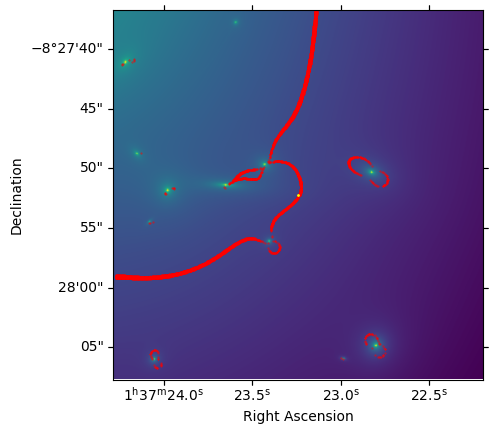

In [35]:
ax = plt.subplot(projection=image_plane.wcs)
ax.imshow(np.log10(abs(conv)),origin="lower")
ax.scatter(mag_line[:,0],mag_line[:,1],s=0.1,color="red",transform=ax.get_transform('world'))
ax.scatter(24.3468342,-8.4645026,s=1,color="yellow",transform=ax.get_transform('world'))
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

In [36]:
lens.trace_points([[24.3468342,-8.4645026]],6.2)

array([24.35380691, -8.45843597])

In [37]:
from silmaril.galaxy import Galaxy
galaxy = Galaxy("../silmaril/docs/source/notebooks/pos_00447_468_99_myr.txt",redshift=6.2,size=200,center=SkyCoord(24.35378054, -8.45843384,unit="deg"))   # center of the galaxy on the source plane?
observation = imaging.Observation(detector,lens,galaxy)

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

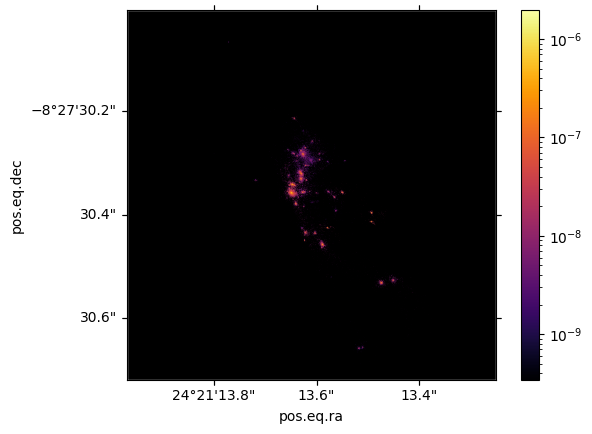

In [38]:

# from silmaril.silmaril import data
galaxy.plot(resolution=1000, zoom_factor = 10)

In [39]:
galaxy.pixel_scale(resolution=1000,zoom_factor=1)

7.122787209721472e-05

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

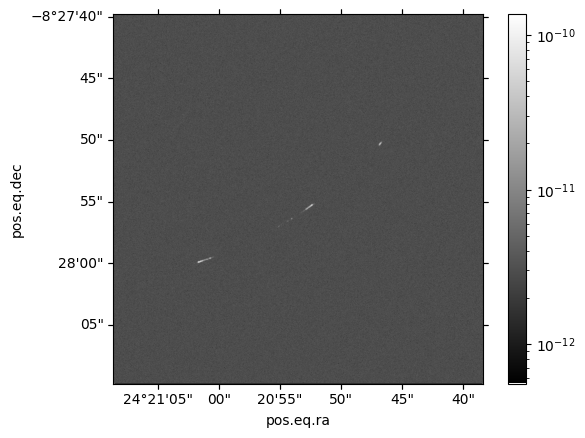

In [40]:
lensed_image = observation.simulate_observation(background=3e-12,noise=5e-13,source_resolution=1000,star_by_star=True)
observation.plot(background=3e-12,noise=5e-13,source_resolution=1000,star_by_star=True)

## Picking the slit center so it lies on the arc 
To see the lensing effect, the slit has to be on the critical line on the image plane, which ultimatey creates the arc on the lensed image. <br>
Now, here are the steps:
- smooth the lensed image as the lensed image can have very sharp local maxima that are not good representatives of the arc as a whole. Smoothing makes the extended arc structure stand out more clearly. <br>
    - gausian_filter(image, sigma): small sigma → very little smoothing, large sigma → heavy blurring
- Determine a thershold value that determines the brightest pixel to keep (arcs should be the brighest pixels)
- We need to seperate multiple arcs. Choose the biggest one
- Find the center of the arc (geometric)

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label, center_of_mass
from astropy.coordinates import SkyCoord
import astropy.units as u

# 1. smooth image
img_smooth = gaussian_filter(lensed_image, sigma=1.5)

# 2. threshold: the pixel value such that 99.5% of pixels are below it.
threshold = np.percentile(img_smooth, 99.5)
mask = img_smooth > threshold  # boolean array (same size as lensed_image) that stores T/F whether the pixel vlaue at each pixel greater than the thershold value

# 3. connected components (seperates multiple arcs if there are)
labels, num = label(mask)

print("Number of bright components:", num)   # if num is large, too agressive thershold. If num is small, too weak thershold

# 4. pick the largest component 
best_label = None
best_size = 0

for lab in range(1, num + 1):  # Among all bright connected regions, keep the biggest one
    size = np.sum(labels == lab)
    if size > best_size:
        best_size = size
        best_label = lab

arc_mask = (labels == best_label)

print("Chosen component label:", best_label)
print("Chosen component size:", best_size)

# 5. centroid of the chosen arc component. This gives the geometric center of the selected region.
y_c, x_c = center_of_mass(arc_mask)

# convert to sky coord
ra_deg, dec_deg = observation.detector.wcs.all_pix2world(x_c, y_c, 0)
arc_point = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)

print("Arc point:", arc_point)
print("Arc point hms/dms:", arc_point.to_string('hmsdms'))
print(f"arc_point = SkyCoord({arc_point.ra.deg:.8f}, {arc_point.dec.deg:.8f}, unit='deg')")

Number of bright components: 891
Chosen component label: 274
Chosen component size: 462
Arc point: <SkyCoord (ICRS): (ra, dec) in deg
    (24.35031068, -8.46660075)>
Arc point hms/dms: 01h37m24.07456216s -08d27m59.76268272s
arc_point = SkyCoord(24.35031068, -8.46660075, unit='deg')


#### Creating the slit
slit size ==> rectangle (0.03 = width, 3 pixels length)

In [42]:
# slit_center = SkyCoord(24.3468342,-8.4645026,unit="deg")
slit_center = SkyCoord(24.35031731, -8.46660400, unit='deg')  #(redshift = 6.2)
# slit_center = SkyCoord(24.34598806, -8.46400919, unit='deg')  # (redshift = 8.33)
# slit_center = SkyCoord(24.34564443, -8.46399715, unit='deg')  # redshift = ds.current_redshift
# slit_width = 30* 0.031 * u.arcsec #arcsec  (1 pixel = 0.031 arcsec in JWST)
# slit_height = 10 * 0.031 * u.arcsec # arcsec (3 pixels)
slit_width = 3.3 * u.arcsec
slit_height = 0.2 * u.arcsec

# creating four points (in world coordinates (RA - right ascending/DEC - declination))
half_width  = slit_width / 2
half_height = slit_height / 2
 
v1 = slit_center.spherical_offsets_by(-half_width,  -half_height)     # bottom-left cornor
v2 = slit_center.spherical_offsets_by(+half_width,  -half_height)     # bottom-right cornor
v3 = slit_center.spherical_offsets_by(+half_width,  +half_height)     # top-right cornor
v4 = slit_center.spherical_offsets_by(-half_width,  +half_height)     # top-left cornor

vertices = [v1, v2, v3, v4]

# traced_points can take a list of points
points = np.array([
    [v.ra.deg, v.dec.deg] for v in vertices
])
print(points)

[[24.34985393 -8.46663178]
 [24.35078069 -8.46663178]
 [24.35078069 -8.46657622]
 [24.34985393 -8.46657622]]


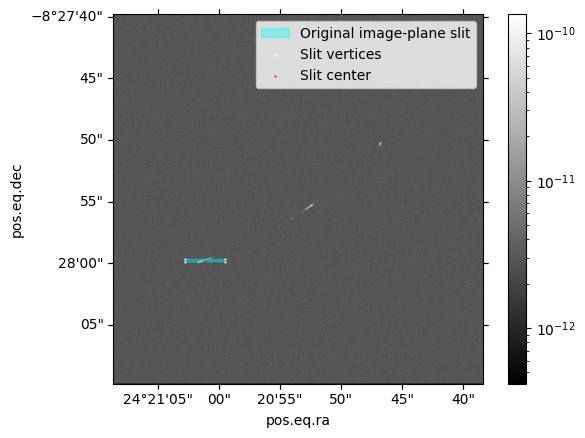

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from astropy.coordinates import SkyCoord
import astropy.units as u

# Plot lensed image
fig, ax = observation.plot(
    background=3e-12,
    noise=5e-13,
    source_resolution=1000,
    star_by_star=True
)

# ----------------------------
# Original image-plane slit vertices
# ----------------------------
# points has shape (4,2): [[ra1, dec1], [ra2, dec2], [ra3, dec3], [ra4, dec4]]
# This should be made from v1, v2, v3, v4 BEFORE tracing:
# points = np.array([[v.ra.deg, v.dec.deg] for v in vertices])

ra_vertices = points[:, 0]
dec_vertices = points[:, 1]

# Convert world coordinates to detector pixels
x_pix, y_pix = observation.detector.wcs.all_world2pix(
    ra_vertices,
    dec_vertices,
    0
)

original_slit_pix = np.column_stack((x_pix, y_pix))

# ----------------------------
# Add original slit polygon
# ----------------------------
slit_poly = Polygon(
    original_slit_pix,
    closed=True,
    edgecolor='cyan',
    facecolor='cyan',
    alpha=0.35,
    linewidth=1,
    label='Original image-plane slit'
)

ax.add_patch(slit_poly)

# Plot slit vertices
ax.scatter(
    x_pix,
    y_pix,
    color='white',
    s=1,
    marker='.',
    label='Slit vertices'
)

# ----------------------------
# Plot slit center
# ----------------------------
x_center, y_center = observation.detector.wcs.all_world2pix(
    slit_center.ra.deg,
    slit_center.dec.deg,
    0
)

ax.scatter(
    x_center,
    y_center,
    color='red',
    s=1,
    marker='.',
    label='Slit center'
)

ax.legend()
plt.show()

In [44]:
traced_points = lens.trace_points(points, 12.171087046255657)  # returns the traced points in this order: [ra1, ra2, ra3, ra4, dec1, dec2, dec3, dec4]

# ---------------------------------------
# nice ordering for each traced points (RA, DEC)
# ---------------------------------------

# number of vertices
n = len(points)
# split and stack
ra_traced  = traced_points[:n]  
dec_traced = traced_points[n:]

traced_points_ordered = np.column_stack((ra_traced, dec_traced))   #stacking two 1D arrays in two sepration cols

print(traced_points_ordered)


[[24.35391473 -8.45816728]
 [24.35398039 -8.45789614]
 [24.35399538 -8.45785189]
 [24.35393303 -8.45812409]]


In [45]:
galaxy_center = SkyCoord(24.35378054, -8.45843384,unit="deg")    # at sky

# ---------------
# ------ findinig offset of the traced points from the galaxy center at sky -----
# ---------------

# first, making the traced points a skycoordinate object
traced_sky = SkyCoord(
    traced_points_ordered[:,0] * u.deg,
    traced_points_ordered[:,1] * u.deg
)

# calculating offsets
d_ra, d_dec = galaxy_center.spherical_offsets_to(traced_sky)                              # manually, d_ra = (ra_points - ra_galaxy) * cos(dec_galaxy), d_dec = (dec_points - dec.galaxy)

# converting to arcsec
d_ra_arcsec  = d_ra.to(u.arcsec).value
d_dec_arcsec = d_dec.to(u.arcsec).value

source_vertices_offset_arcsec = np.column_stack((d_ra_arcsec, d_dec_arcsec))  # arcsec

print(source_vertices_offset_arcsec)


[[0.47781563 0.95963271]
 [0.71164458 1.93573066]
 [0.76500125 2.09501411]
 [0.54297955 1.11508925]]


# Lance Summary

This is the output for the kpc position of the slit on the galaxy, and needs to be integrated into the slit projection script

In [46]:
# converting to physcial units
cosmo = FlatLambdaCDM(H0=70 * u.km/u.s/u.Mpc, Om0=0.3)
z_source = 6.2
angular_diam_dist_source = cosmo.angular_diameter_distance(z_source).to(u.kpc).value  # kpc 

# converting arcsec to distance
arcsec_to_rad = np.pi / (180 * 3600)

theta_x = d_ra_arcsec  * arcsec_to_rad
theta_y = d_dec_arcsec * arcsec_to_rad

x_kpc = theta_x * angular_diam_dist_source
y_kpc = theta_y * angular_diam_dist_source

print(x_kpc)
print(y_kpc)
source_vertices_offset_kpc = np.column_stack((x_kpc, y_kpc))

print(source_vertices_offset_kpc)

[2.67986217 3.9913081  4.29056273 3.04533859]
[ 5.38216675 10.85668    11.75003228  6.25405556]
[[ 2.67986217  5.38216675]
 [ 3.9913081  10.85668   ]
 [ 4.29056273 11.75003228]
 [ 3.04533859  6.25405556]]


#### plottting the ploygon in the source plane

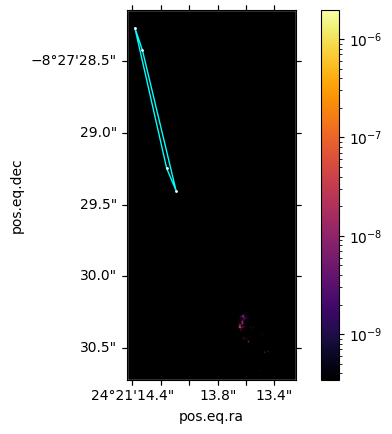

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# plotting galaxy (WCS axes)
fig, ax = galaxy.plot(resolution=1000, zoom_factor=10)

# creating polygon
slit_polygon = Polygon(
    traced_points_ordered,
    closed=True,
    edgecolor='cyan',
    facecolor='none',  
    linewidth=1,
    transform=ax.get_transform('world')  )

# adding to plot
ax.add_patch(slit_polygon)

# showing vertices
ax.scatter(
    traced_points_ordered[:, 0],
    traced_points_ordered[:, 1],
    color='white',
    s=1,
    transform=ax.get_transform('world')
)

plt.show()

In [48]:
# traced_points_ordered has shape (4,2) = [[ra1, dec1], [ra2, dec2], ...]
traced_vertices = SkyCoord(
    ra=traced_points_ordered[:, 0] * u.deg,
    dec=traced_points_ordered[:, 1] * u.deg
)

print("Traced slit side lengths:")
for i in range(4):                                            # 
    j = (i + 1) % 4   # next vertex, wrapping around
    side_length = traced_vertices[i].separation(traced_vertices[j])
    print(f"Side v{i+1}-v{j+1}: {side_length.to(u.arcsec):.6f}")

Traced slit side lengths:
Side v1-v2: 1.003715 arcsec
Side v2-v3: 0.167983 arcsec
Side v3-v4: 1.004762 arcsec
Side v4-v1: 0.168562 arcsec


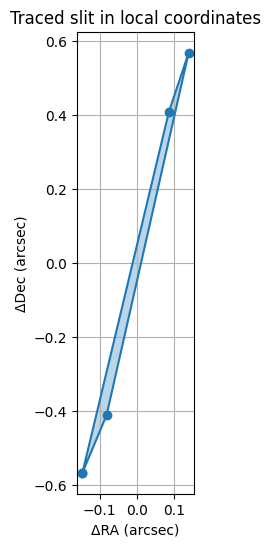

In [49]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

# use first traced vertex array
traced_sky = SkyCoord(
    traced_points_ordered[:,0] * u.deg,
    traced_points_ordered[:,1] * u.deg
)

# choose reference point = centroid of slit
ref = SkyCoord(
    traced_points_ordered[:,0].mean() * u.deg,
    traced_points_ordered[:,1].mean() * u.deg
)

dx, dy = ref.spherical_offsets_to(traced_sky)

x = dx.to(u.arcsec).value
y = dy.to(u.arcsec).value

# close the polygon
x_plot = np.append(x, x[0])
y_plot = np.append(y, y[0])

plt.figure(figsize=(6,6))
plt.plot(x_plot, y_plot, '-o')
plt.fill(x_plot, y_plot, alpha=0.3)
plt.xlabel("ΔRA (arcsec)")
plt.ylabel("ΔDec (arcsec)")
plt.title("Traced slit in local coordinates")
plt.gca().set_aspect('equal')
plt.grid(True)
plt.show()

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

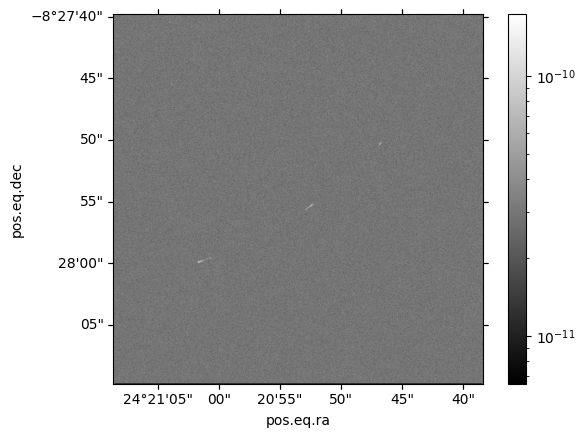

In [50]:
observation.plot(background=3e-11,noise=5e-12,source_resolution=1000,star_by_star=True)

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

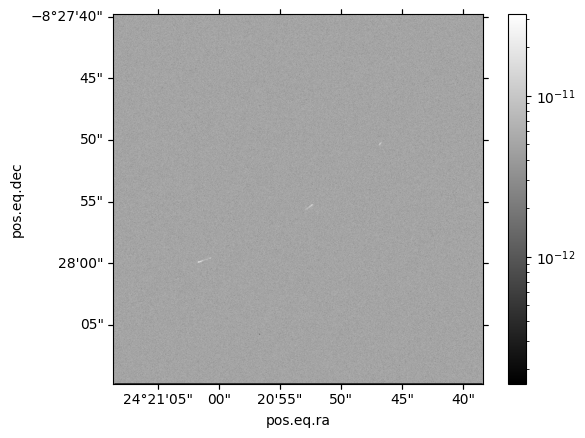

In [51]:
observation.plot(background=5e-12,noise=1e-12,source_resolution=1000,filter_name="F200W")

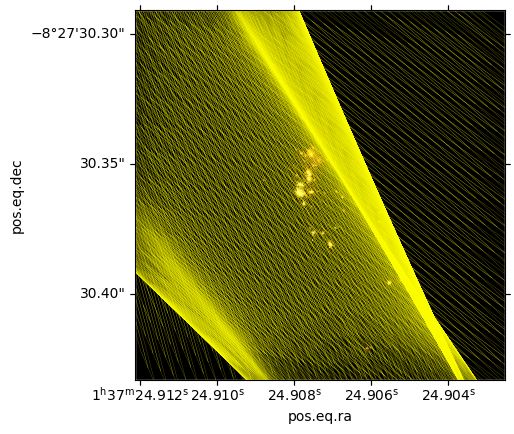

In [52]:
from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib.colors import LogNorm
nonempty_pixels, arc_pixels, polygons, luminosities = observation.trace_pixels(source_resolution=1000,zoom_factor=2)

ax = plt.subplot(projection=galaxy.grid(1000,2).wcs)
ax.imshow(galaxy.create_image(resolution=1000,zoom_factor=2),norm=LogNorm(1e-9,1e-7),cmap="inferno")
polygons = [Polygon(p,closed=True,fill=False,color="yellow",lw=0.1,transform=ax.get_transform('world')) for p in polygons]

ax.set_facecolor('black')
for i,p in enumerate(polygons):
    ax.add_patch(p)